# 01 · Controllo e pulizia — Incendi boschivi Puglia 2017–2024

**File:** `dataset-incendi-vito-martella.csv` (incendi di bosco, macchia mediterranea e canneti)

Obiettivo: capire la qualità del dataset, **segnalare** i problemi e produrre una versione pulita.

Regole seguite in tutto il notebook:
1. **Il file originale non si tocca.** Si legge da `data/raw/`, si scrive in `data/clean/`.
2. **Niente cancellazioni silenziose.** Le righe dubbie restano, ma vengono marcate con colonne `flag_*`: sarete voi a decidere se escluderle in un'analisi.
3. **Si corregge solo ciò che è certo** (es. caratteri accentati rovinati). Ciò che è solo sospetto (es. coordinate) viene segnalato, non "aggiustato" a occhio.
4. Ogni riga pulita conserva `id_riga`, il numero di riga nel file originale, per poterla sempre ritrovare.

In [1]:

from pathlib import Path
import warnings, json, urllib.request
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")
pd.set_option("display.width", 200)
pd.set_option("display.max_columns", 30)
pd.set_option("display.max_colwidth", 60)

# Struttura attesa del progetto:
#   data/raw/    -> CSV originali (non vanno MAI modificati)
#   data/ref/    -> dati di riferimento scaricati (confini comunali ISTAT)
#   data/clean/  -> CSV puliti + report dei problemi
ROOT = Path(".").resolve()
RAW, REF, CLEAN = ROOT / "data" / "raw", ROOT / "data" / "ref", ROOT / "data" / "clean"
for d in (RAW, REF, CLEAN):
    d.mkdir(parents=True, exist_ok=True)

RAW_FILE = RAW / "dataset-incendi-vito-martella.csv"
print(RAW_FILE, RAW_FILE.exists())

/home/claude/proj/data/raw/dataset-incendi-vito-martella.csv True


In [2]:

# Registro dei problemi: ogni controllo aggiunge una riga, alla fine lo salviamo come CSV.
problemi = []
def segnala(controllo, gravita, n_righe, dettaglio, azione):
    """gravita: 'ALTA' (dato probabilmente sbagliato), 'MEDIA' (da verificare), 'BASSA' (cosmetico)."""
    problemi.append(dict(controllo=controllo, gravita=gravita, n_righe=int(n_righe),
                         dettaglio=dettaglio, azione=azione))
    print(f"[{gravita}] {controllo}: {n_righe} righe -> {azione}")


## 1. Formato del file
Prima di caricarlo con pandas guardiamo i byte: separatore, codifica, fine riga.

In [3]:
raw_bytes = RAW_FILE.read_bytes()
print("BOM UTF-8 all'inizio:", raw_bytes.startswith(b"\xef\xbb\xbf"))
print("Fine riga Windows (CRLF):", b"\r\n" in raw_bytes)
print("Prima riga:", raw_bytes.splitlines()[0].decode("utf-8-sig"))

BOM UTF-8 all'inizio: True
Fine riga Windows (CRLF): True
Prima riga: DATA;COMUNE;LOCALITA';LAT;LONG;TIPOLOGIA;CODICE COL;PROV;ANNO


Separatore `;`, codifica UTF-8 con BOM, righe in stile Windows. La colonna `LOCALITA'` ha un apostrofo nel nome: la rinomineremo.

In [4]:
df_raw = pd.read_csv(RAW_FILE, sep=";", encoding="utf-8-sig", dtype=str, keep_default_na=False)
df_raw.index.name = "id_riga"
print(df_raw.shape)
df_raw.head()

(3853, 9)


,DATA,COMUNE,LOCALITA',LAT,LONG,TIPOLOGIA,CODICE COL,PROV,ANNO
id_riga,,,,,,,,,
0,2024-04-07,Gravina in Puglia,C.da Albanello,40.788722,16.438278,Bosco,Arancione,BARI,2024
1,2024-05-06,Altamura,Sant'Antonio,40.88,16.68025,Bosco,Arancione,BARI,2024
2,2024-06-10,Gioia del Colle,S.C. Casotta,40.816099,16.902061,Macchia,Arancione,BARI,2024
3,2024-06-11,Grumo Appula,Quadrifoglio,40.912644,16.695124,Macchia,Arancione,BARI,2024
4,2024-06-18,Gravina in Puglia,Masseria Lorusso,40.773349,16.48619,Bosco,Arancione,BARI,2024


In [5]:
df = df_raw.rename(columns={"DATA": "data", "COMUNE": "comune", "LOCALITA'": "localita",
                            "LAT": "lat", "LONG": "lon", "TIPOLOGIA": "tipologia",
                            "CODICE COL": "codice_colore", "PROV": "prov_orig", "ANNO": "anno"}).copy()
# Valori vuoti
vuoti = (df.apply(lambda s: s.str.strip()) == "").sum()
print("Celle vuote per colonna:\n", vuoti[vuoti > 0])

Celle vuote per colonna:
 localita    53
dtype: int64


In [6]:
segnala("localita mancante", "BASSA", vuoti.get("localita", 0),
        "Nessuna descrizione della localita'", "Lasciate vuote (NaN); non influiscono su data e coordinate")
df["localita"] = df["localita"].replace("", np.nan)

[BASSA] localita mancante: 53 righe -> Lasciate vuote (NaN); non influiscono su data e coordinate


## 2. Caratteri accentati rovinati (*mojibake*)
Alcuni testi contengono `Ó`, `¨`, `ý`, `░` al posto di `à`, `ù`, `ì`, `°`.
È il classico errore di un file salvato in codifica Windows (cp1252) e riletto come DOS (cp850).
La correzione è **deterministica**: ricostruiamo la tabella di conversione e sostituiamo carattere per carattere
(non l'intera stringa, perché alcune righe contengono già accenti corretti come in *Nardò*).

In [7]:
MOJIBAKE = {c.encode("cp1252").decode("cp850"): c for c in "àèéìíòóùÀÈÉÌÒÙ°"}
print(MOJIBAKE)

def ripara(s):
    if not isinstance(s, str):
        return s
    return "".join(MOJIBAKE.get(ch, ch) for ch in s)

for col in ["comune", "localita"]:
    mask = df[col].fillna("").map(lambda s: any(ch in MOJIBAKE for ch in s))
    esempi = df.loc[mask, col].drop_duplicates().head(6).tolist()
    print(f"\n{col}: {mask.sum()} righe da riparare. Esempi: {esempi}")
    print("  dopo:", [ripara(e) for e in esempi])
    segnala(f"mojibake in {col}", "MEDIA" if col == "comune" else "BASSA", mask.sum(),
            "Accenti corrotti (cp1252 letto come cp850), es. 'Pat¨' -> 'Patù'",
            "Corretto automaticamente")
    df[col] = df[col].map(ripara)

{'Ó': 'à', 'Þ': 'è', 'Ú': 'é', 'ý': 'ì', 'Ý': 'í', '‗': 'ò', '¾': 'ó', '¨': 'ù', '└': 'À', '╚': 'È', '╔': 'É', '╠': 'Ì', 'Ê': 'Ò', '┘': 'Ù', '░': '°'}

comune: 2 righe da riparare. Esempi: ['Pat¨', 'Seclý']
  dopo: ['Patù', 'Seclì']
[MEDIA] mojibake in comune: 2 righe -> Corretto automaticamente

localita: 57 righe da riparare. Esempi: ['La PietÓ', 'localitÓ PietÓ bosco Marcedde', 'Monte PietÓ', 'Via PietÓ - Bosco Marcedd', "localitÓ sant'Antonio", 'localitÓ cimitero']
  dopo: ['La Pietà', 'località Pietà bosco Marcedde', 'Monte Pietà', 'Via Pietà - Bosco Marcedd', "località sant'Antonio", 'località cimitero']
[BASSA] mojibake in localita: 57 righe -> Corretto automaticamente


Altri problemi di testo: caratteri persi del tutto (sostituiti da `?`, non recuperabili), barre rovesciate, spazi doppi.

In [8]:
persi = df["localita"].fillna("").str.contains(r"\?", regex=True)
print(df.loc[persi, "localita"].tolist())
segnala("caratteri persi in localita", "BASSA", persi.sum(),
        "Caratteri sostituiti da '?' nel file originale (es. 'd?Oronzo', '???')",
        "Non recuperabili: marcati con flag_localita_incompleta")
df["flag_localita_incompleta"] = persi

prima = df["localita"].copy()
df["localita"] = (df["localita"].str.replace("\\'", "'", regex=False)   # \' -> '
                                .str.replace(r"\s+", " ", regex=True)    # spazi multipli
                                .str.strip())
cambiate = (prima.fillna("") != df["localita"].fillna("")).sum()
segnala("spazi / barre rovesciate in localita", "BASSA", cambiate,
        "Spazi doppi o apostrofi con backslash", "Normalizzati")

['???', 'ss 16 ???', 'Casino Canale d?Oronzo']
[BASSA] caratteri persi in localita: 3 righe -> Non recuperabili: marcati con flag_localita_incompleta
[BASSA] spazi / barre rovesciate in localita: 47 righe -> Normalizzati


## 3. Comuni e province
Confrontiamo i nomi con l'elenco ufficiale ISTAT e verifichiamo che la provincia dichiarata sia quella giusta.

In [9]:

# Confini comunali della Puglia (ISTAT, ripubblicati da openpolis/geojson-italy).
# Servono per: 1) validare i nomi dei comuni  2) verificare che le coordinate cadano nel comune dichiarato.
GEOJSON_URL = ("https://raw.githubusercontent.com/openpolis/geojson-italy/master/"
               "geojson/limits_R_16_municipalities.geojson")
GEOJSON = REF / "puglia_comuni.geojson"
if not GEOJSON.exists():
    urllib.request.urlretrieve(GEOJSON_URL, GEOJSON)

comuni = gpd.read_file(GEOJSON)[["name", "com_istat_code", "prov_acr", "geometry"]]
comuni = comuni.rename(columns={"name": "comune", "com_istat_code": "comune_istat", "prov_acr": "provincia"})
print(f"Comuni di riferimento: {len(comuni)} (la Puglia ne ha 257)")
COMUNE2ISTAT = dict(zip(comuni.comune, comuni.comune_istat))
COMUNE2PROV = dict(zip(comuni.comune, comuni.provincia))


Comuni di riferimento: 257 (la Puglia ne ha 257)


In [10]:
non_trovati = sorted(set(df["comune"]) - set(COMUNE2ISTAT))
print("Comuni non riconosciuti dopo la riparazione degli accenti:", non_trovati)
if non_trovati:
    segnala("comune non riconosciuto", "ALTA", df["comune"].isin(non_trovati).sum(),
            f"Nomi non presenti in ISTAT: {non_trovati}", "Da correggere a mano")
df["comune_istat"] = df["comune"].map(COMUNE2ISTAT)
print("Comuni distinti nel dataset:", df["comune"].nunique(), "su 257")

Comuni non riconosciuti dopo la riparazione degli accenti: []
Comuni distinti nel dataset: 223 su 257


In [11]:
PROV_SIGLA = {"BARI": "BA", "BAT": "BT", "BRINDISI": "BR", "FOGGIA": "FG", "LECCE": "LE", "TARANTO": "TA"}
print("Valori originali:", df["prov_orig"].unique())
df["provincia"] = df["prov_orig"].map(PROV_SIGLA)
incoerenti = df["provincia"] != df["comune"].map(COMUNE2PROV)
print("Righe con provincia incoerente col comune:", incoerenti.sum())
if incoerenti.sum():
    segnala("provincia incoerente", "ALTA", incoerenti.sum(), "Provincia diversa da quella ISTAT del comune", "Da verificare")
df = df.drop(columns="prov_orig")

Valori originali: <StringArray>
['BARI', 'BAT', 'BRINDISI', 'FOGGIA', 'LECCE', 'TARANTO']
Length: 6, dtype: str
Righe con provincia incoerente col comune: 0


## 4. Date e anno

In [12]:
df["data"] = pd.to_datetime(df["data"], format="%Y-%m-%d", errors="coerce")
df["anno"] = pd.to_numeric(df["anno"], errors="coerce").astype("Int64")
print("Date non valide:", df["data"].isna().sum())
print("Intervallo:", df["data"].min().date(), "->", df["data"].max().date())
print("ANNO diverso dall'anno della data:", (df["data"].dt.year != df["anno"]).sum())
df["mese"] = df["data"].dt.month

Date non valide: 0
Intervallo: 2017-04-13 -> 2024-11-12
ANNO diverso dall'anno della data: 0


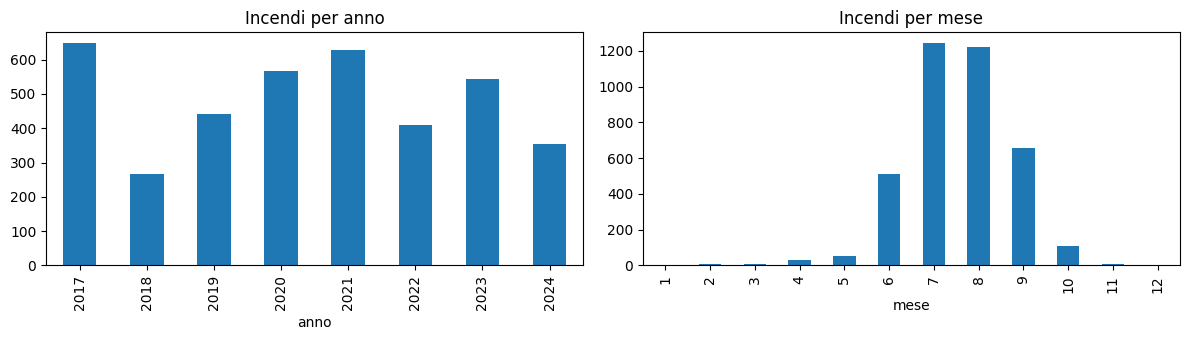

In [13]:
fig, ax = plt.subplots(1, 2, figsize=(12, 3.5))
df["anno"].value_counts().sort_index().plot.bar(ax=ax[0], title="Incendi per anno")
df["mese"].value_counts().reindex(range(1, 13), fill_value=0).plot.bar(ax=ax[1], title="Incendi per mese")
plt.tight_layout(); plt.show()

**Da notare:** il 2018 ha molti meno eventi degli altri anni (266 contro 400–650).
Può essere un anno davvero meno critico oppure una registrazione incompleta: dai dati da soli non si può dire.
Va chiesto a chi ha prodotto il dataset prima di usare il 2018 in confronti tra anni.

In [14]:
per_anno = df["anno"].value_counts()
segnala("anno con pochi eventi", "MEDIA", per_anno.get(2018, 0),
        f"2018: {per_anno.get(2018, 0)} eventi vs mediana {int(per_anno.median())}",
        "Nessuna modifica; possibile incompletezza da verificare con la fonte")

[MEDIA] anno con pochi eventi: 266 righe -> Nessuna modifica; possibile incompletezza da verificare con la fonte


## 5. Categorie: tipologia e codice colore

In [15]:
print(df["tipologia"].value_counts(), "\n")
print(df["codice_colore"].value_counts(), "\n")
pd.crosstab(df["anno"], df["codice_colore"], margins=True)

tipologia
Bosco      1535
Macchia    1324
Canneto     994
Name: count, dtype: int64 

codice_colore
Arancione    2630
Giallo       1000
Verde         129
Rosso          91
Bianco          3
Name: count, dtype: int64 



codice_colore,Arancione,Bianco,Giallo,Rosso,Verde,All
anno,,,,,,
2017,374,3,140,66,64,647
2018,147,0,82,2,35,266
2019,280,0,133,8,20,441
2020,404,0,155,0,7,566
2021,498,0,125,2,2,627
2022,277,0,129,1,1,408
2023,384,0,155,4,0,543
2024,266,0,81,8,0,355
All,2630,3,1000,91,129,3853


Il campo `codice_colore` viene mantenuto così com'è, senza vincoli rispetto alla tipologia di vegetazione:
un incendio in un canneto può avere qualsiasi colore.

`Verde` e `Bianco` non sono descritti nella scheda del dataset: è stata inviata una richiesta di chiarimento al referente.
I bianchi compaiono solo nel 2017 e i verdi diminuiscono negli anni fino a sparire dal 2023 (vedi tabella sopra).

In [16]:
segnala("codici colore Verde/Bianco", "BASSA", df["codice_colore"].isin(["Verde", "Bianco"]).sum(),
        "Valori non descritti nella scheda del dataset", "Mantenuti; chiarimento richiesto al referente")

[BASSA] codici colore Verde/Bianco: 132 righe -> Mantenuti; chiarimento richiesto al referente


## 6. Coordinate
Quattro controlli:
1. valori numerici e dentro un riquadro plausibile della Puglia;
2. **precisione**: con 2 decimali l'errore può arrivare a ~1 km;
3. il punto cade **nel comune dichiarato**?
4. se no, **a che distanza** dal confine comunale?

In [17]:
decimali = df["lat"].str.split(".").str[1].str.len().fillna(0)
df["lat"] = pd.to_numeric(df["lat"], errors="coerce")
df["lon"] = pd.to_numeric(df["lon"], errors="coerce")
print("Coordinate non numeriche:", df[["lat", "lon"]].isna().any(axis=1).sum())
print("Decimali della latitudine:", decimali.value_counts().sort_index().to_dict())

df["flag_coord_bassa_precisione"] = decimali <= 2
segnala("coordinate a bassa precisione", "BASSA", df["flag_coord_bassa_precisione"].sum(),
        "Latitudine con 2 o meno decimali (errore fino a ~1 km)", "Marcate con flag_coord_bassa_precisione")

Coordinate non numeriche: 0
Decimali della latitudine: {1: 2, 2: 27, 3: 117, 4: 116, 5: 209, 6: 3375, 7: 6, 8: 1}
[BASSA] coordinate a bassa precisione: 29 righe -> Marcate con flag_coord_bassa_precisione


In [18]:
# Distanza di ogni punto dal poligono del SUO comune (0 = dentro). Proiezione UTM 33N per avere metri.
pts = gpd.GeoSeries(gpd.points_from_xy(df["lon"], df["lat"]), index=df.index, crs=4326).to_crs(32633)
poly = comuni.set_index("comune").to_crs(32633).geometry
df["dist_comune_km"] = [round(p.distance(poly[c]) / 1000, 3) if c in poly.index else np.nan
                        for p, c in zip(pts, df["comune"])]

# In quale comune cade davvero il punto?
dove = gpd.sjoin(gpd.GeoDataFrame(geometry=pts.to_crs(4326)), comuni[["comune", "geometry"]],
                 how="left", predicate="within")
df["comune_da_coordinate"] = dove["comune"].groupby(level=0).first()

def classe(d):
    if pd.isna(d): return "comune_sconosciuto"
    if d == 0:     return "ok"
    if d <= 1:     return "vicino_confine"   # <= 1 km: tipico di incendi a cavallo tra due comuni
    if d <= 5:     return "da_verificare"
    return "sospetta"
df["flag_coord"] = df["dist_comune_km"].map(classe)
df["flag_coord"].value_counts()

flag_coord
ok                3613
vicino_confine     167
da_verificare       55
sospetta            18
Name: count, dtype: int64

In [19]:
n_vic = (df.flag_coord == "vicino_confine").sum()
n_ver = (df.flag_coord == "da_verificare").sum()
n_sos = (df.flag_coord == "sospetta").sum()
segnala("punto fuori dal comune (<=1 km)", "BASSA", n_vic,
        "Il punto cade in un comune confinante, entro 1 km dal confine", "Accettabile; marcato vicino_confine")
segnala("punto fuori dal comune (1-5 km)", "MEDIA", n_ver,
        "Il punto dista 1-5 km dal comune dichiarato", "Marcato da_verificare")
segnala("punto lontano dal comune (>5 km)", "ALTA", n_sos,
        "Coordinate o comune probabilmente errati (fino a ~50 km, alcuni punti in mare)", "Marcato sospetta")
df.loc[df.flag_coord == "sospetta",
       ["data", "comune", "comune_da_coordinate", "localita", "lat", "lon", "dist_comune_km"]
      ].sort_values("dist_comune_km", ascending=False)

[BASSA] punto fuori dal comune (<=1 km): 167 righe -> Accettabile; marcato vicino_confine
[MEDIA] punto fuori dal comune (1-5 km): 55 righe -> Marcato da_verificare
[ALTA] punto lontano dal comune (>5 km): 18 righe -> Marcato sospetta


,data,comune,comune_da_coordinate,localita,lat,lon,dist_comune_km
id_riga,,,,,,,
2034,2023-10-08,Lecce,Ugento,fontanelle,39.868056,18.153333,49.455
2509,2020-09-27,Trepuzzi,NaN,Via Giuseppe Elia nei pressi,40.412778,18.710528,48.714
2931,2023-06-30,Castellaneta,NaN,conca d'oro,40.303156,16.585977,30.626
3113,2022-07-16,Taranto,Fasano,parco della rimembranza,40.825083,17.450028,26.033
1608,2017-07-10,Monte Sant'Angelo,Apricena,piano san vito,41.765556,15.491111,25.821
2749,2017-07-08,Caprarica di Lecce,Lecce,parco rauccio - sp 93,40.468611,18.169417,21.577
883,2023-09-11,Accadia,Ascoli Satriano,Agata delle Noci,41.202361,15.573667,17.740
1477,2019-09-26,Troia,Foggia,Torrente Sannoro,41.555833,15.568333,17.631
3852,2017-10-14,Massafra,Putignano,Pizziferro,40.835917,17.116306,17.250


Esempi dalla tabella sopra:
- **Trepuzzi**, longitudine `18.710528`: il punto è in mare aperto; il paese è intorno a 18.07. È probabile un errore di battitura, ma **non lo correggiamo a occhio**: va verificato con la fonte.
- **Lecce**, latitudine `39.868`: il punto è vicino a Santa Maria di Leuca, a circa 50 km dal comune.

Le coordinate *da_verificare* e *sospette* vanno escluse dalle analisi spaziali fini (hotspot, cluster), ma restano valide per i conteggi per comune e per data.

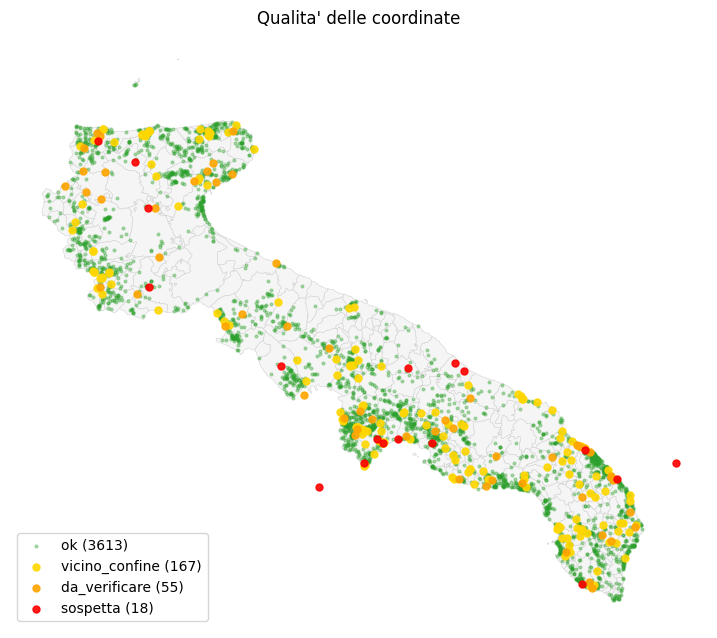

In [20]:
ax = comuni.plot(figsize=(9, 9), color="whitesmoke", edgecolor="lightgrey", linewidth=0.4)
colori = {"ok": "tab:green", "vicino_confine": "gold", "da_verificare": "orange", "sospetta": "red"}
for k, c in colori.items():
    sub = df[df.flag_coord == k]
    ax.scatter(sub.lon, sub.lat, s=4 if k == "ok" else 25, c=c, label=f"{k} ({len(sub)})",
               alpha=0.35 if k == "ok" else 0.9)
ax.legend(loc="lower left"); ax.set_title("Qualita' delle coordinate"); ax.set_axis_off(); plt.show()

## 7. Duplicati
- **Duplicati esatti**: righe identiche in tutto.
- **Possibili duplicati**: stessa data, stesso comune, coordinate uguali entro ~100 m (3 decimali), ma descrizione della località diversa. Potrebbe essere lo stesso incendio registrato due volte, oppure due focolai geolocalizzati nello stesso punto. **Non si possono distinguere dai dati**: li marchiamo e li lasciamo.

In [21]:
esatti = df_raw.duplicated().sum()
print("Duplicati esatti:", esatti)

chiave = (df["data"].astype(str) + "|" + df["comune"] + "|"
          + df["lat"].round(3).astype(str) + "|" + df["lon"].round(3).astype(str))
df["flag_possibile_duplicato"] = chiave.duplicated(keep=False)
df["gruppo_duplicato"] = np.where(df["flag_possibile_duplicato"], chiave.factorize()[0], -1)
segnala("possibili duplicati", "MEDIA", df["flag_possibile_duplicato"].sum(),
        "Stessa data, comune e coordinate (~100 m) con localita' diverse",
        "Mantenuti; marcati con flag_possibile_duplicato e gruppo_duplicato")
df.loc[df.flag_possibile_duplicato, ["gruppo_duplicato", "data", "comune", "localita", "tipologia", "lat", "lon"]
      ].sort_values("gruppo_duplicato")

Duplicati esatti: 0
[MEDIA] possibili duplicati: 14 righe -> Mantenuti; marcati con flag_possibile_duplicato e gruppo_duplicato


,gruppo_duplicato,data,comune,localita,tipologia,lat,lon
id_riga,,,,,,,
429,429,2022-06-25,Andria,viale Madama Camilla c/o Boschetto Sant'Agostino - cocevola,Bosco,41.168702,16.286471
430,429,2022-06-25,Andria,Contrada Cocevola,Bosco,41.168702,16.286471
530,529,2017-07-23,Spinazzola,Via Alfieri,Macchia,40.973083,16.080000
531,529,2017-07-23,Spinazzola,Pilone - prolungam. via Alfieri,Macchia,40.973083,16.080000
1138,1136,2021-08-11,Castelluccio Valmaggiore,SP 125 Fondo Valle,Canneto,41.364167,15.238889
1139,1136,2021-08-11,Castelluccio Valmaggiore,vicinanze polli / fotovoltaico,Canneto,41.364167,15.238889
1406,1403,2019-08-07,Carlantino,Colle Torto/Diga Occhito,Bosco,41.609861,14.966278
1407,1403,2019-08-07,Carlantino,lago di occhito verso Colletorto (CB),Bosco,41.609861,14.966278
3231,3227,2021-07-08,Castellaneta,Lama di Noci-Calia,Macchia,40.590861,16.907667


In [22]:
stesso_giorno = df.groupby(["data", "comune"]).size()
print("Coppie data+comune con piu' incendi:", (stesso_giorno > 1).sum(),
      "-> normale: nello stesso comune possono esserci piu' focolai in un giorno. Non e' un errore.")

Coppie data+comune con piu' incendi: 215 -> normale: nello stesso comune possono esserci piu' focolai in un giorno. Non e' un errore.


## 8. Salvataggio

In [23]:
COLONNE = ["data", "anno", "mese", "comune", "comune_istat", "provincia", "localita", "lat", "lon",
           "tipologia", "codice_colore", "dist_comune_km", "comune_da_coordinate", "flag_coord",
           "flag_coord_bassa_precisione", "flag_possibile_duplicato", "gruppo_duplicato",
           "flag_localita_incompleta"]
clean = df[COLONNE].reset_index()          # id_riga = riga nel file originale (0 = prima riga di dati)
clean["data"] = clean["data"].dt.strftime("%Y-%m-%d")
clean.to_csv(CLEAN / "incendi_clean.csv", index=False, encoding="utf-8")

report = pd.DataFrame(problemi)
report.to_csv(CLEAN / "incendi_problemi.csv", index=False, encoding="utf-8")
print("Salvati:", CLEAN / "incendi_clean.csv", clean.shape)
report

Salvati: /home/claude/proj/data/clean/incendi_clean.csv (3853, 19)


,controllo,gravita,n_righe,dettaglio,azione
0,localita mancante,BASSA,53,Nessuna descrizione della localita',Lasciate vuote (NaN); non influiscono su data e coordinate
1,mojibake in comune,MEDIA,2,"Accenti corrotti (cp1252 letto come cp850), es. 'Pat¨' -...",Corretto automaticamente
2,mojibake in localita,BASSA,57,"Accenti corrotti (cp1252 letto come cp850), es. 'Pat¨' -...",Corretto automaticamente
3,caratteri persi in localita,BASSA,3,Caratteri sostituiti da '?' nel file originale (es. 'd?O...,Non recuperabili: marcati con flag_localita_incompleta
4,spazi / barre rovesciate in localita,BASSA,47,Spazi doppi o apostrofi con backslash,Normalizzati
5,anno con pochi eventi,MEDIA,266,2018: 266 eventi vs mediana 492,Nessuna modifica; possibile incompletezza da verificare ...
6,codici colore Verde/Bianco,BASSA,132,Valori non descritti nella scheda del dataset,Mantenuti; chiarimento richiesto al referente
7,coordinate a bassa precisione,BASSA,29,Latitudine con 2 o meno decimali (errore fino a ~1 km),Marcate con flag_coord_bassa_precisione
8,punto fuori dal comune (<=1 km),BASSA,167,"Il punto cade in un comune confinante, entro 1 km dal co...",Accettabile; marcato vicino_confine
9,punto fuori dal comune (1-5 km),MEDIA,55,Il punto dista 1-5 km dal comune dichiarato,Marcato da_verificare


### Righe "affidabili" per l'analisi spaziale
Un filtro consigliato per mappe e hotspot:
```python
buone = clean[clean.flag_coord.isin(["ok", "vicino_confine"]) & ~clean.flag_coord_bassa_precisione]
```

In [24]:
buone = clean[clean.flag_coord.isin(["ok", "vicino_confine"]) & ~clean.flag_coord_bassa_precisione]
print(f"Righe adatte ad analisi spaziali fini: {len(buone)} su {len(clean)} ({len(buone)/len(clean):.1%})")

Righe adatte ad analisi spaziali fini: 3751 su 3853 (97.4%)
